# Model SARIMA - Sèrie temporal 2

Aquest notebook analitza la sèrie temporal setmanal de casos d’Altres IRA en població de 15 anys o més a la regió BCN Nord durant el període 2012–2024, seguint la metodologia Box-Jenkins.

El procediment és el següent:

1. Identificació del model
2. Estimació del model
3. Validació
4. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", InterpolationWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.simplefilter("ignore", ConvergenceWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["diagnostic"] == "Altres IRA") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

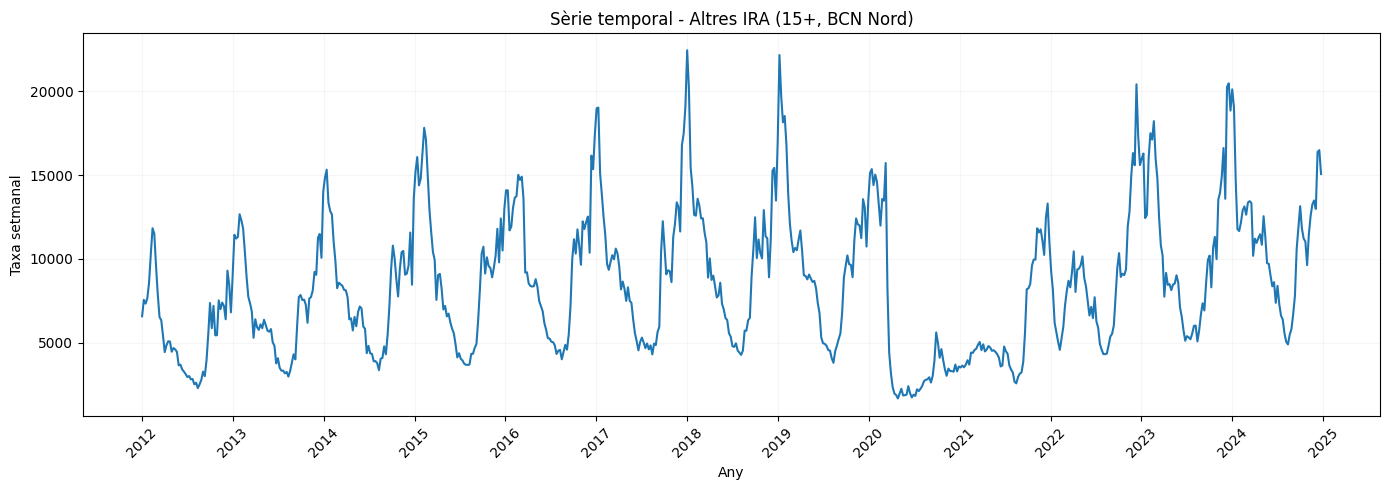

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Altres IRA (15+, BCN Nord)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## Divisió Entrenament-Avaluació

La sèrie es divideix en un conjunt d’entrenament (període 2012-2019) i un conjunt d’avaluació (període 2020-2024)

In [4]:
serie_2 = serie.copy()

train = serie_2[serie_2.index < "2020-01-01"]
test  = serie_2[serie_2.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

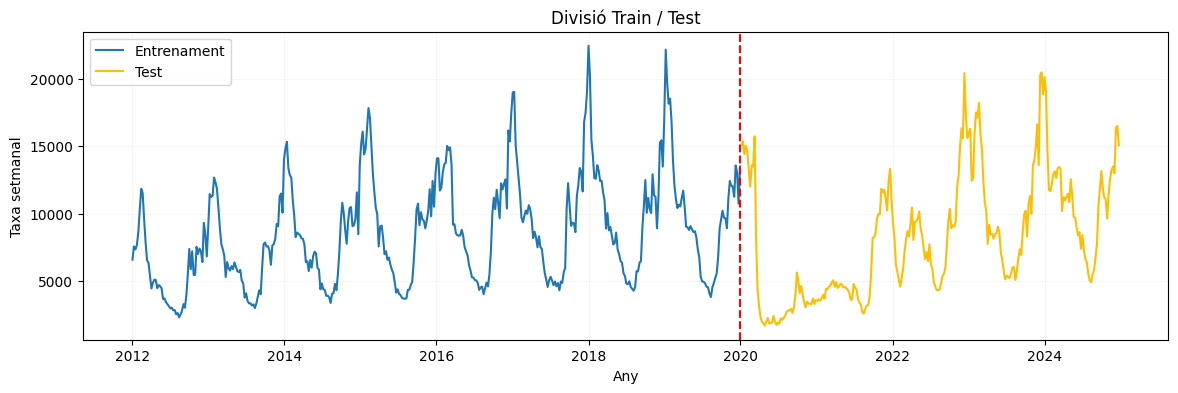

In [5]:
plt.figure(figsize=(14,4))

plt.plot(train, label="Entrenament", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.grid(alpha=0.1)
plt.show()

## Identificació del model

En aquesta fase s’analitza la sèrie d’entrenament per determinar les transformacions necessàries i proposar un conjunt reduït de models SARIMA candidats. Es considera l’estabilitat de la mitjana i la variància, la presència d’estacionalitat anual i la necessitat de diferenciació regular i estacional. Finalment, s’analitzen l’ACF i la PACF de la sèrie transformada per identificar els ordres del model.

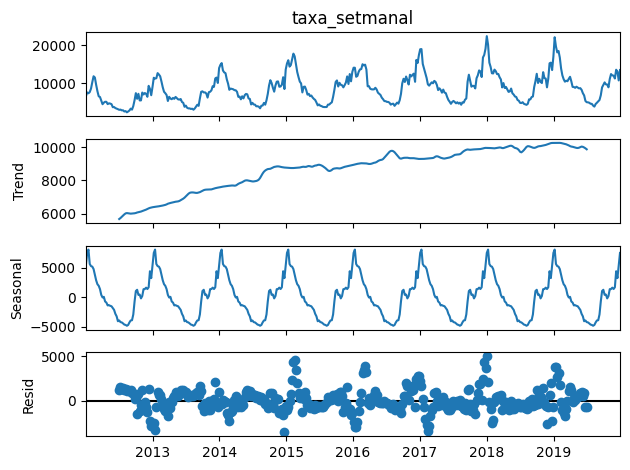

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

### Transformació logarítmica

Es comparen la sèrie original i la sèrie transformada logarítmicament, juntament amb la seva mitjana i variància mòbils. Com que la variabilitat és més elevada en els períodes amb valors més alts, s’utilitza la transformació logarítmica per estabilitzar parcialment la variància.

Mitjana global (train): 8550.028668482193
Variància global (train): 14871678.95775331

Mitjana per any:
date
2012-12-31    5708.116743
2013-12-31    7086.500405
2014-12-31    7937.845806
2015-12-31    8945.744775
2016-12-31    9508.455428
2017-12-31    9469.804797
2018-12-31    9922.266702
2019-12-31    9849.757651
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    6.010920e+06
2013-12-31    8.475888e+06
2014-12-31    9.373031e+06
2015-12-31    1.601566e+07
2016-12-31    1.431834e+07
2017-12-31    1.646238e+07
2018-12-31    1.667655e+07
2019-12-31    1.722288e+07
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


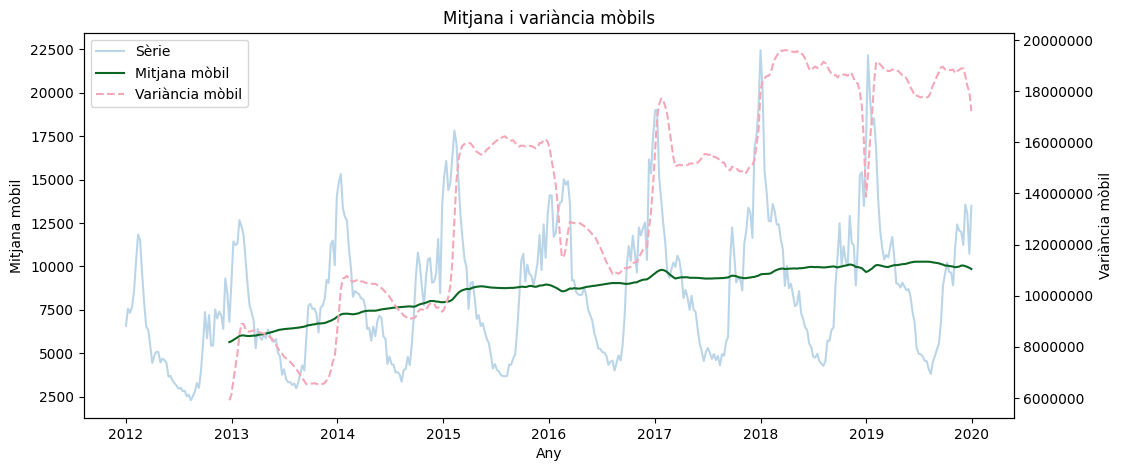

In [7]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)
ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")

plt.title("Mitjana i variància mòbils")
plt.show()

Mitjana global (train_log): 8.94973617768974
Variància global (train_log): 0.21770649210849538

 Mitjana per any:
date
2012-12-31    8.555711
2013-12-31    8.780633
2014-12-31    8.904041
2015-12-31    8.994350
2016-12-31    9.074271
2017-12-31    9.067446
2018-12-31    9.118664
2019-12-31    9.107102
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    0.198757
2013-12-31    0.180062
2014-12-31    0.159242
2015-12-31    0.224150
2016-12-31    0.185267
2017-12-31    0.182477
2018-12-31    0.176279
2019-12-31    0.186979
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


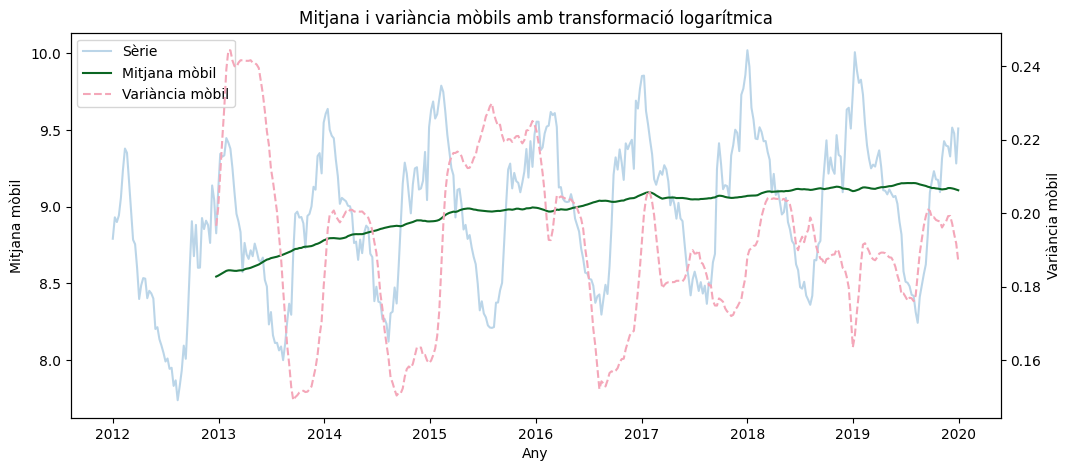

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print("Mitjana global (train_log):", train_log.mean())
print("Variància global (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_meanlog, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")
plt.title("Mitjana i variància mòbils amb transformació logarítmica")
plt.show()

### ACF i diferenciació estacional

A continuació, s’analitza l’ACF de la sèrie logarítmica. Els pics en retards propers al període anual, m=52, indiquen una dependència estacional clara.

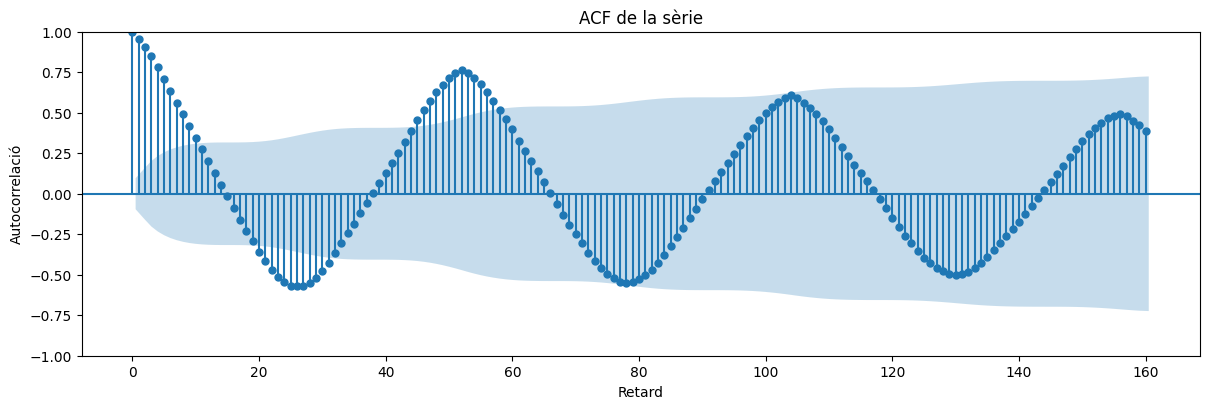

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF de la sèrie")
plt.tight_layout()
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.show()

Per comprovar l’efecte de la diferenciació estacional, es compara la sèrie abans i després d’aplicar D=1, així com les seves ACF corresponents. Després de la diferenciació estacional, la dependència anual es redueix de manera substancial. Per tant, es fixa D=1 amb període m=52.

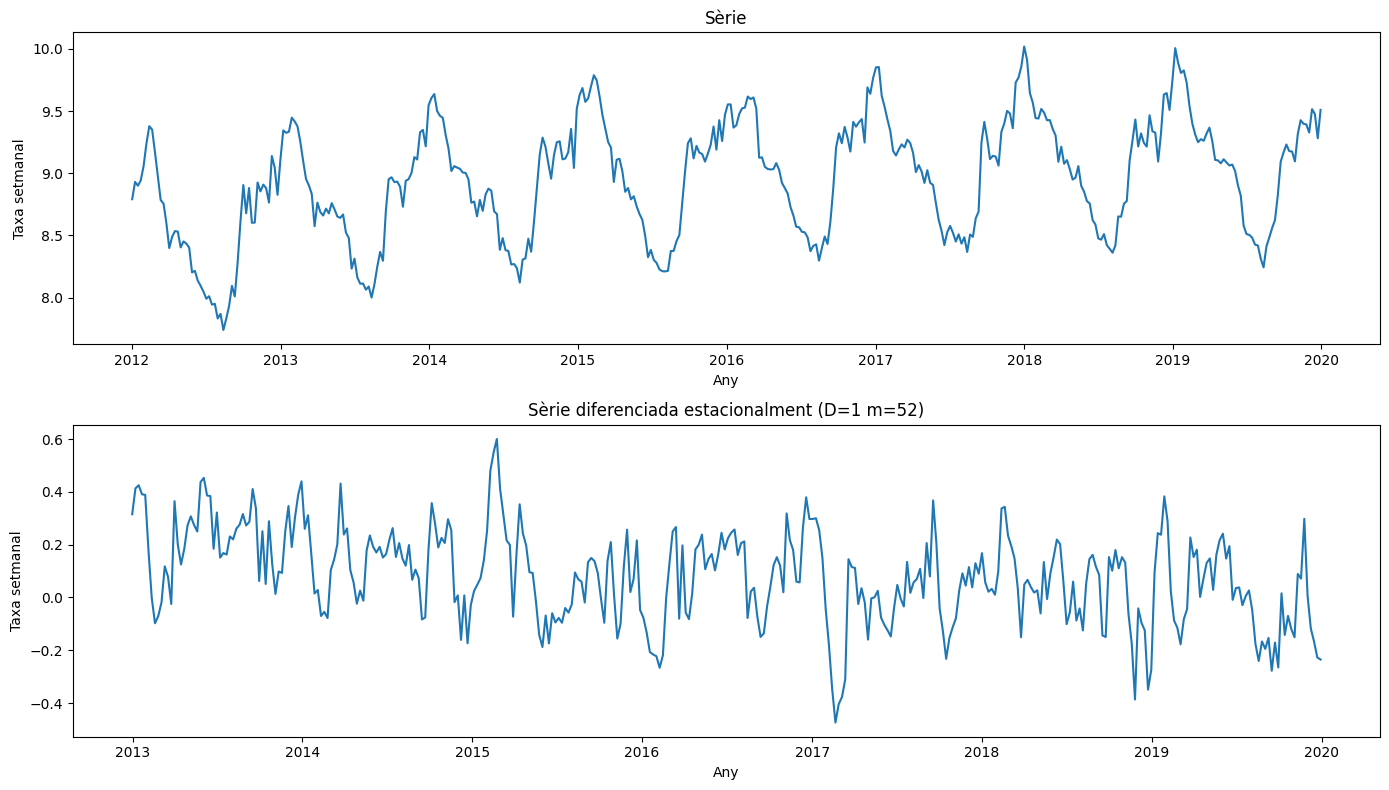

In [10]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Sèrie")
axes[0].set_ylabel("Taxa setmanal")
axes[0].set_xlabel("Any")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1 m=52)")
axes[1].set_ylabel("Taxa setmanal")
axes[1].set_xlabel("Any")

plt.tight_layout()
plt.show()

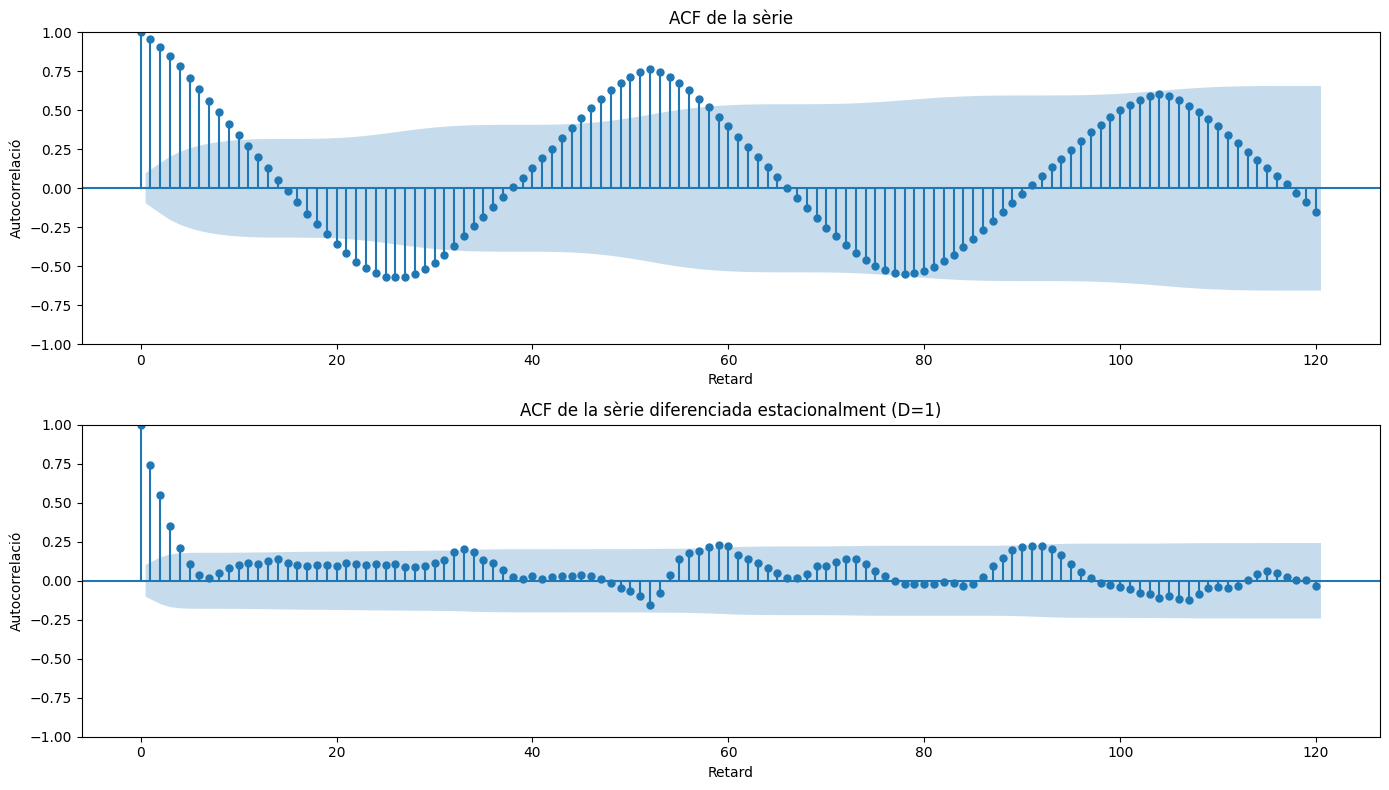

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")


plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada estacionalment (D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació")


plt.tight_layout()
plt.show()

### Comprovació de la diferenciació regular

Un cop considerada la transformació logarítmica i la diferenciació estacional, s’avalua si també és necessària una diferenciació regular. Aquesta decisió es basa en si la mitjana és constant, en l'ACF i es reforça mitjançant els tests ADF i KPSS.

In [12]:
adf_pvalor = adfuller(serie_D1, autolag="AIC")[1]
kpss_pvalor = kpss(serie_D1, regression="c", nlags="auto")[1]

def format_pvalor(p, test):
    if test == "ADF" and p < 0.001:
        return "< 0.001"
    if test == "KPSS" and p >= 0.10:
        return "> 0.10"
    return f"{p:.4f}"

conclusio_adf = (
    "Es rebutja H0: evidència d’estacionarietat"
    if adf_pvalor < 0.05
    else "No es rebutja H0: possible no estacionarietat"
)

conclusio_kpss = (
    "No es rebutja H0: compatible amb estacionarietat"
    if kpss_pvalor >= 0.05
    else "Es rebutja H0: evidència de no estacionarietat"
)

taula_tests = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "p-valor": [
        format_pvalor(adf_pvalor, "ADF"),
        format_pvalor(kpss_pvalor, "KPSS")
    ],
    "Conclusió": [conclusio_adf, conclusio_kpss]
})

taula_tests

,Test,p-valor,Conclusió
0,ADF,< 0.001,Es rebutja H0: evidència d’estacionarietat
1,KPSS,0.0100,Es rebutja H0: evidència de no estacionarietat


Els resultats dels tests ADF i KPSS no són completament coincidents. El test ADF rebutja la hipòtesi nul·la d’arrel unitària, mentre que el test KPSS rebutja la hipòtesi d’estacionarietat. Per aquest motiu, la decisió sobre la diferenciació no es basa únicament en aquests contrastos, sinó que es complementa amb l’anàlisi gràfica de l’ACF i la PACF. En conjunt, es considera adequat aplicar diferenciació regular i estacional.


### Identificació dels ordres ARMA

Un cop seleccionades la transformació logarítmica i la diferenciació regular i estacional (d=1, D=1), s’analitzen l’ACF i la PACF de la sèrie resultant.

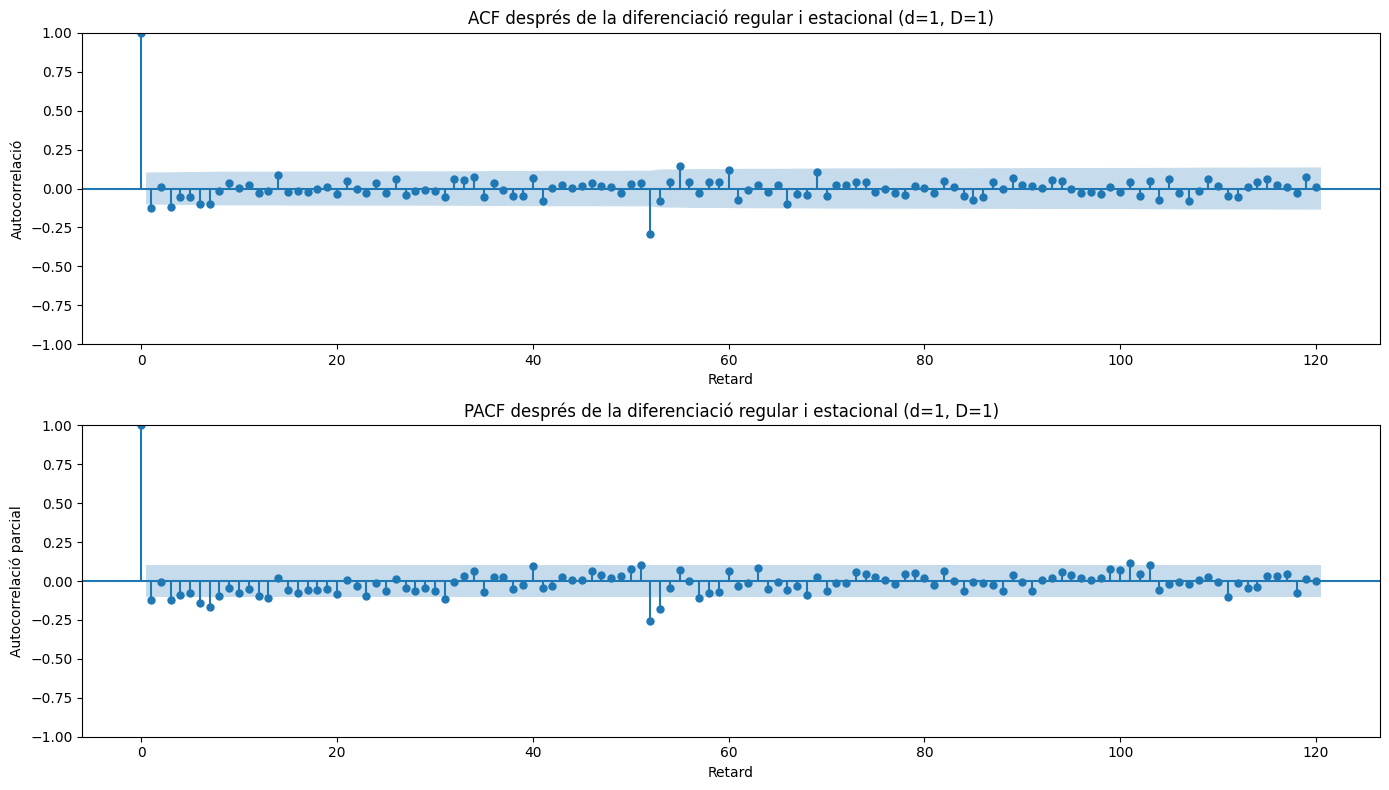

In [13]:
serie_d1D1 = serie_D1.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_d1D1, lags=120, ax=axes[0])
axes[0].set_title("ACF després de la diferenciació regular i estacional (d=1, D=1)")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_d1D1, lags=120, ax=axes[1])
axes[1].set_title("PACF després de la diferenciació regular i estacional (d=1, D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

### Anàlisi de l’ACF i la PACF

Després d’aplicar la transformació logarítmica, la diferenciació estacional (D=1) i la diferenciació regular (d=1), l’estructura d’autocorrelació queda més estabilitzada. L’ACF mostra dependència a curt termini i algun efecte en retards estacionals, mentre que la PACF no presenta un patró de tall clar. Per això, es proposen models SARIMA amb ordres regulars baixos i una estructura estacional senzilla.

## Estimació dels models candidats

S’ajusten diversos models SARIMA candidats a partir dels ordres identificats amb l’ACF i la PACF. La primera comparació es fa mitjançant l’AIC, amb l’objectiu de retenir un conjunt reduït de models per a la validació residual posterior. 

In [14]:
best_aic = float("inf")
best_model = None
best_results = None

models = [
    ((0,1,1), (0,1,1,52)),
    ((1,1,1), (0,1,1,52)),
    ((1,1,1), (0,1,0,52)),
    ((1,1,2), (0,1,0,52)),
    ((1,1,2), (0,1,1,52)), 
    ((2,1,2), (0,1,0,52)),
    ((2,1,1), (0,1,0,52)),
    ((0,1,2), (0,1,0,52)), 
    ((2,1,0), (0,1,0,52)),    

]
for order, seasonal_order in models:
    print(f"Provant model SARIMA {order}{seasonal_order}")

    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results = model.fit(
            disp=False,
            maxiter=1000,
            method="lbfgs"
        )

        converged = results.mle_retvals.get("converged", False)

        if not converged:
            results_refined = model.fit(
                start_params=results.params,
                disp=False,
                maxiter=3000,
                method="lbfgs"
            )

            if results_refined.mle_retvals.get("converged", False):
                results = results_refined
                converged = True

        print(f"AIC: {results.aic}")
        print(f"Convergència: {converged}")

        if converged:
            if results.aic < best_aic:
                best_aic = results.aic
                best_model = (order, seasonal_order)
                best_results = results
        else:
            print("Model descartat perquè no convergeix.")

        print("-" * 40)

    except Exception as e:
        print(f"Error en el model SARIMA {order}{seasonal_order}: {e}")
        print("-" * 40)

print("\nMillor model:")
print(best_model)
print("AIC:", best_aic)

Provant model SARIMA (0, 1, 1)(0, 1, 1, 52)
AIC: -473.7337840489298
Convergència: True
----------------------------------------
Provant model SARIMA (1, 1, 1)(0, 1, 1, 52)
AIC: -472.20238910062926
Convergència: True
----------------------------------------
Provant model SARIMA (1, 1, 1)(0, 1, 0, 52)
AIC: -525.067946643986
Convergència: True
----------------------------------------
Provant model SARIMA (1, 1, 2)(0, 1, 0, 52)
AIC: -520.8622921263299
Convergència: True
----------------------------------------
Provant model SARIMA (1, 1, 2)(0, 1, 1, 52)
AIC: -463.60633649450494
Convergència: True
----------------------------------------
Provant model SARIMA (2, 1, 2)(0, 1, 0, 52)
AIC: -519.7202465108609
Convergència: True
----------------------------------------
Provant model SARIMA (2, 1, 1)(0, 1, 0, 52)
AIC: -480.9830397963208
Convergència: True
----------------------------------------
Provant model SARIMA (0, 1, 2)(0, 1, 0, 52)
AIC: -481.0761421504207
Convergència: True
----------------

### Selecció preliminar de models

No es selecciona automàticament el model amb menor AIC. Es retenen els tres models amb millor AIC per comparar-ne també la significació dels coeficients, la parsimònia i el comportament dels residus.

In [15]:
model1 = SARIMAX(train_log,
                order=(1,1,1),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 52)   Log Likelihood                 265.534
Date:                             Tue, 09 Jun 2026   AIC                           -525.068
Time:                                     19:17:29   BIC                           -513.385
Sample:                                 01-02-2012   HQIC                          -520.424
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7145      0.039     18.365      0.000       0.638       0.791
ma.L1         -0.9816      

In [16]:
model2 = SARIMAX(train_log,
                order=(1,1,2),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(0, 1, [], 52)   Log Likelihood                 264.431
Date:                             Tue, 09 Jun 2026   AIC                           -520.862
Time:                                     19:17:30   BIC                           -505.296
Sample:                                 01-02-2012   HQIC                          -514.674
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7025      0.055     12.824      0.000       0.595       0.810
ma.L1         -0.9585      

In [17]:
model3 = SARIMAX(train_log,
                order=(2,1,2),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 52)   Log Likelihood                 264.860
Date:                             Tue, 09 Jun 2026   AIC                           -519.720
Time:                                     19:17:31   BIC                           -500.262
Sample:                                 01-02-2012   HQIC                          -511.985
                                      - 12-30-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0453      0.477     -0.095      0.924      -0.981       0.890
ar.L2          0.5611      

## Validació dels models preseleccionats

Els tres models preseleccionats s’avaluen mitjançant el diagnòstic dels residus. Es compara el gràfic dels residus, l’ACF dels residus i el contrast de Ljung-Box per retards regulars i estacionals per valorar si els residus es poden considerar aproximadament soroll blanc.

Burn-in utilitzat: 55


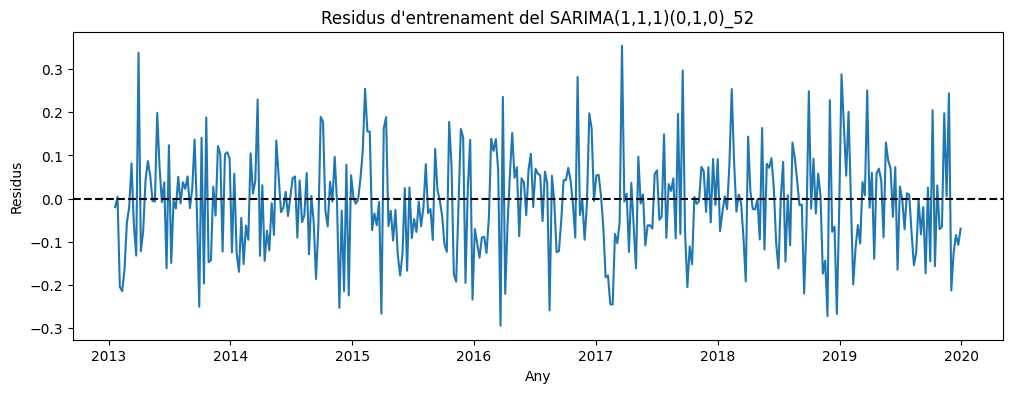

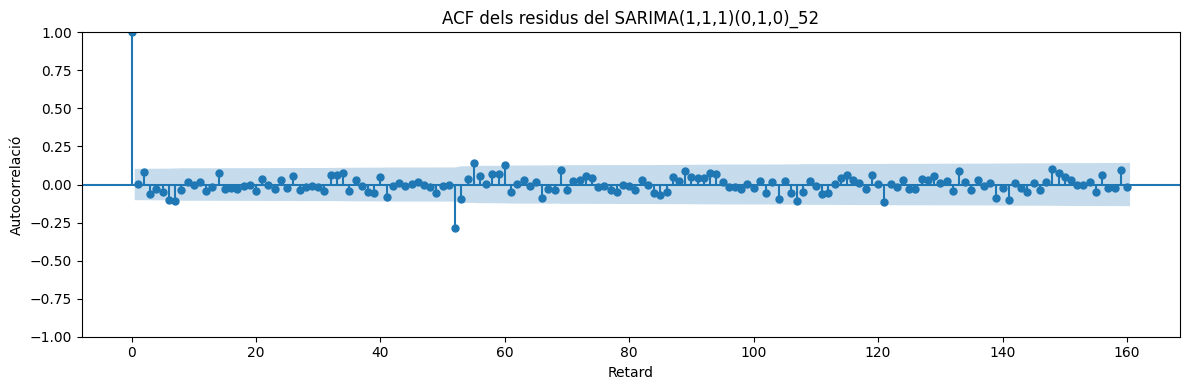


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  14.036548   0.080818
20  18.491295   0.423756
30  21.932341   0.784414

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    72.779644   0.019379
104  140.045675   0.007438

Mitjana dels residus: -0.011096313490586185


In [18]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual1)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(1,1,1)(0,1,0)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual1, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(1,1,1)(0,1,0)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.tight_layout()
plt.show()


model_df = 1 + 1 + 0 + 0

ljung_box = acorr_ljungbox(
    residual1,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual1,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual1.mean())

Burn-in utilitzat: 56


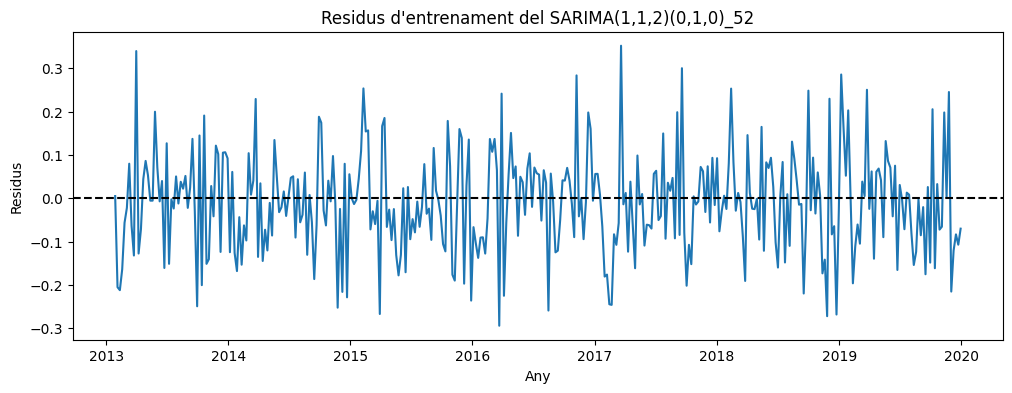

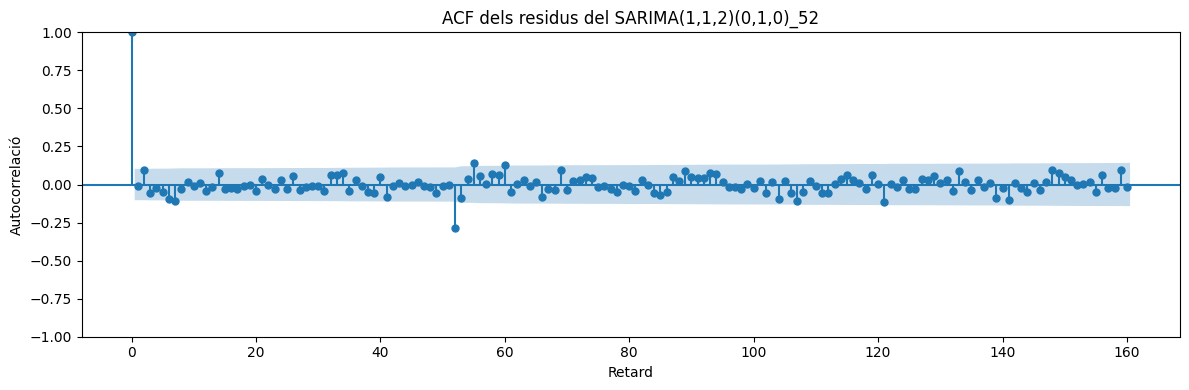


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  13.726672   0.056262
20  18.220401   0.375066
30  21.716480   0.751641

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    72.057260   0.017649
104  138.542478   0.007837

Mitjana dels residus: -0.01108719452532921


In [19]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual2)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(1,1,2)(0,1,0)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual2, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(1,1,2)(0,1,0)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")
plt.tight_layout()
plt.show()


model_df = 1 + 2 + 0 + 0

ljung_box = acorr_ljungbox(
    residual2,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual2,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual2.mean())

Burn-in utilitzat: 56


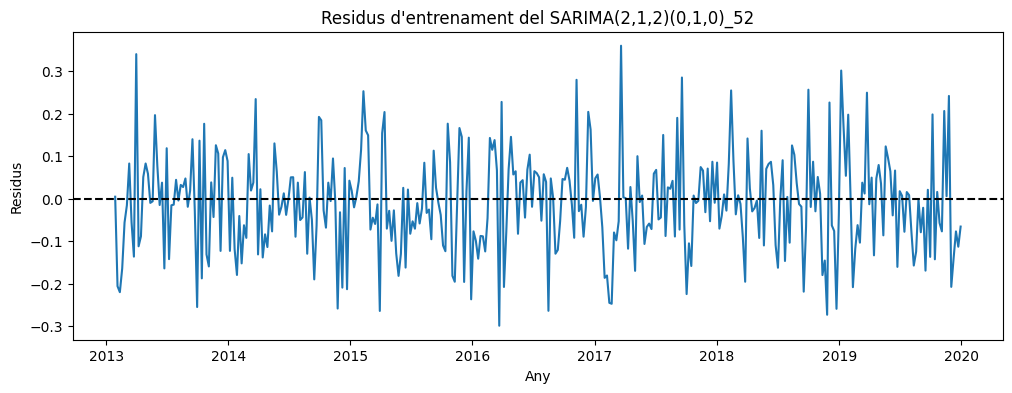

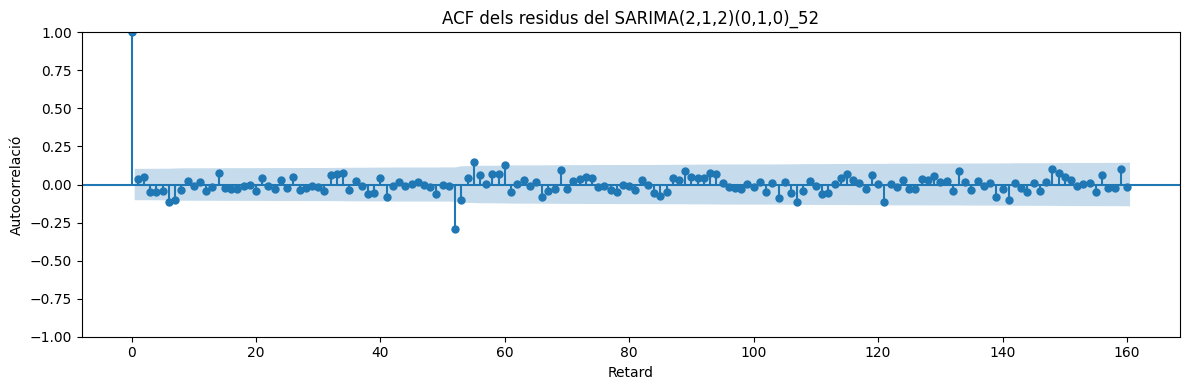


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  13.364469   0.037600
20  18.045176   0.321258
30  21.342703   0.724065

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    73.225921   0.010978
104  141.540382   0.003987

Mitjana dels residus: -0.011053513733106552


In [20]:
residuals= result3.resid.dropna()
burn = max(result3.loglikelihood_burn, result3.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual3 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual3)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(2,1,2)(0,1,0)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual3, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(2,1,2)(0,1,0)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")
plt.tight_layout()
plt.show()


model_df = 2 + 2 + 0 + 0

ljung_box = acorr_ljungbox(
    residual3,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual3,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual3.mean())

### Elecció del model final

Se selecciona el model SARIMA(1,1,1)(0,1,0)_{52}, ja que presenta el menor AIC entre els models candidats. El diagnòstic dels residus és raonable en els retards regulars, tot i que encara apareix certa dependència en retards estacionals. Això indica que el model captura bona part del patró de la sèrie, però no elimina completament l’estructura estacional residual. Malgrat això, s’ha mantingut aquest model perquè ofereix el millor equilibri entre ajust, simplicitat i comportament residual.


## Predicció SARIMA

Amb el model final seleccionat, es generen prediccions per al període 2020-2024 i es comparen amb els valors observats mitjançant el MAE, el RMSE i la cobertura dels intervals de predicció.

In [21]:
model = SARIMAX(train_log,
                order=(1,1,1),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log) 

In [22]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)
cov_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)
cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)
cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_total],
    "RMSE": [rmse_total],
    "Cobertura": [cov_total]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_covid = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_covid],
    "RMSE": [rmse_covid],
    "Cobertura": [cov_covid]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_post],
    "RMSE": [rmse_post],
    "Cobertura": [cov_post]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

print("\nTOTAL (2020-2024):")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)


TOTAL (2020-2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,3115.758,4281.217,0.723



COVID (2020–2021):


,Model,MAE,RMSE,Cobertura
0,SARIMA,4281.749,5407.176,0.375



POST-COVID (2022–2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,2338.431,3325.106,0.955


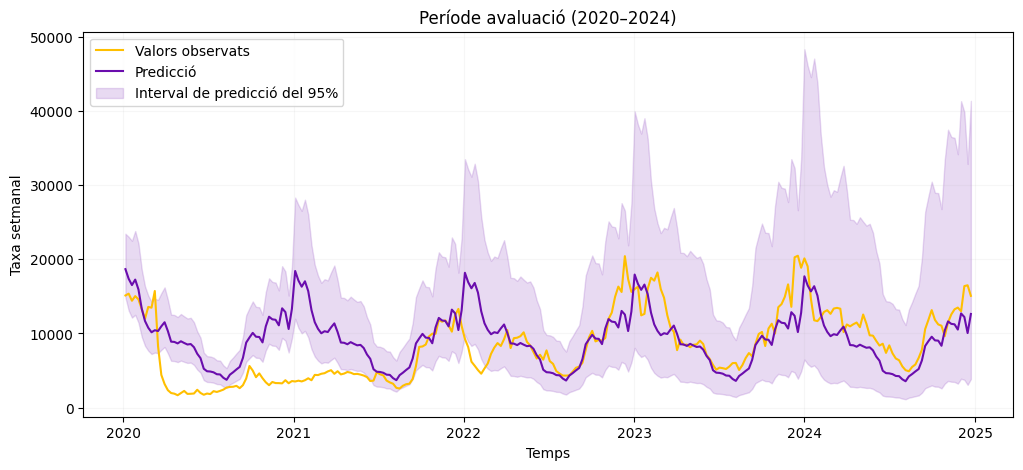

In [23]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període avaluació (2020–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()

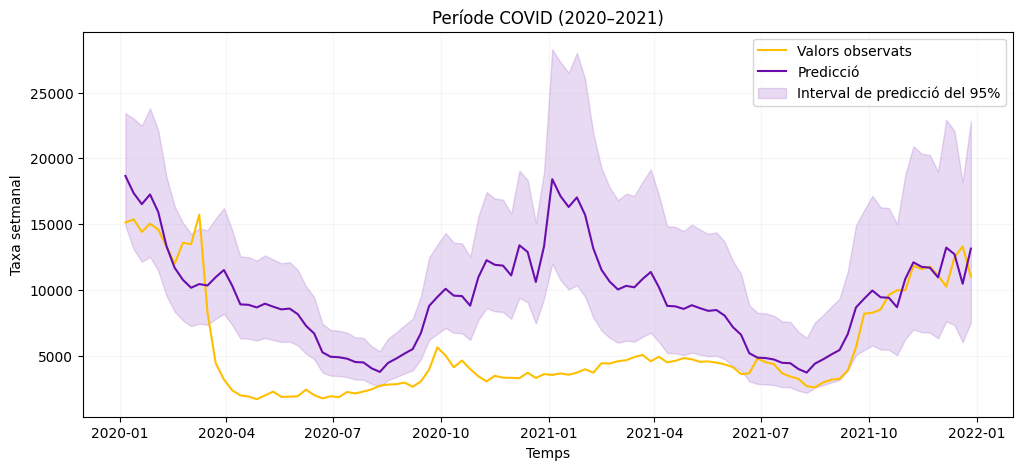

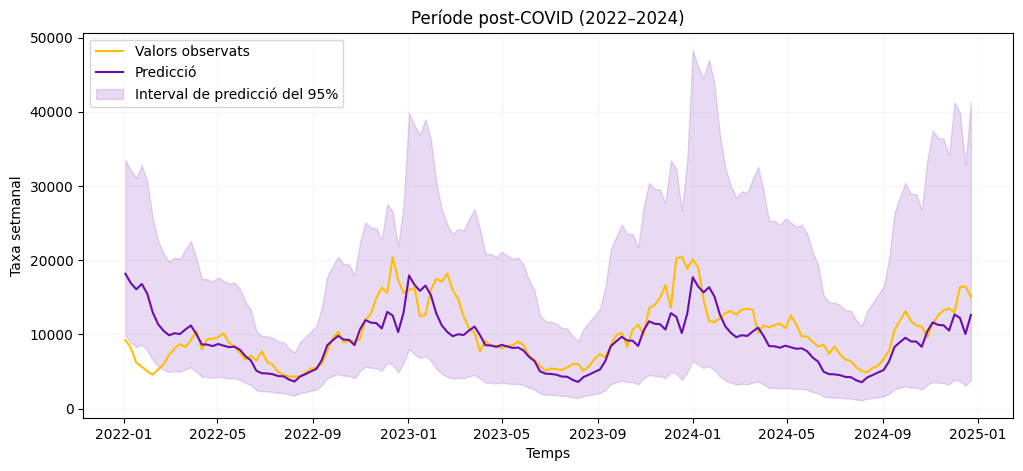

In [24]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()